# Importacion de librerias

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from funciones import  correlacion_vs_target


# Cargue de datos

In [3]:
df_riesgo_desafiliacion = pd.read_csv('../data/raw/base clasificacion.csv', sep=';')

# Exploracion de los datos

In [4]:
df_riesgo_desafiliacion.head()

,id_empresa,nit,sector,antiguedad,tiempo_afiliacion,num_trabajadores,crecimiento_empleo,uso_servicios,satisfaccion,rotacion,salario_promedio,digitalizacion,formalizacion,distancia,abandono
0,1,903373228,Manufactura,2.8,1.5,14,-5.0,3,57.6,27.2,3.13,37.0,43.4,26.6,1
1,2,904494741,Manufactura,13.3,8.1,5,1.0,6,71.4,14.3,3.97,86.9,64.9,0.6,0
2,3,867433090,Tecnología,50.0,44.4,60,9.7,4,57.9,10.7,3.64,51.2,66.7,2.3,0
3,4,843731818,Servicios,7.0,4.4,15,8.8,5,84.8,9.4,1.54,73.7,63.4,4.9,0
4,5,864648907,Servicios,9.5,8.0,48,4.1,4,72.3,11.1,3.87,60.6,94.9,23.3,0


In [5]:
df_riesgo_desafiliacion.isna().sum()

id_empresa            0
nit                   0
sector                0
antiguedad            0
tiempo_afiliacion     0
num_trabajadores      0
crecimiento_empleo    0
uso_servicios         0
satisfaccion          0
rotacion              0
salario_promedio      0
digitalizacion        0
formalizacion         0
distancia             0
abandono              0
dtype: int64

In [6]:
df_riesgo_desafiliacion.duplicated(subset='id_empresa').sum()

0

In [7]:
df_riesgo_desafiliacion.duplicated().sum()

0

In [8]:
df_riesgo_desafiliacion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_empresa          10000 non-null  int64  
 1   nit                 10000 non-null  int64  
 2   sector              10000 non-null  object 
 3   antiguedad          10000 non-null  float64
 4   tiempo_afiliacion   10000 non-null  float64
 5   num_trabajadores    10000 non-null  int64  
 6   crecimiento_empleo  10000 non-null  float64
 7   uso_servicios       10000 non-null  int64  
 8   satisfaccion        10000 non-null  float64
 9   rotacion            10000 non-null  float64
 10  salario_promedio    10000 non-null  float64
 11  digitalizacion      10000 non-null  float64
 12  formalizacion       10000 non-null  float64
 13  distancia           10000 non-null  float64
 14  abandono            10000 non-null  int64  
dtypes: float64(9), int64(5), object(1)
memory usage: 1.1+ 

In [9]:
df_riesgo_desafiliacion.describe()

,id_empresa,nit,antiguedad,tiempo_afiliacion,num_trabajadores,crecimiento_empleo,uso_servicios,satisfaccion,rotacion,salario_promedio,digitalizacion,formalizacion,distancia,abandono
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,9.001005e+08,11.375700,6.871550,36.730000,5.08695,4.660000,65.790540,17.065640,3.529728,59.669520,60.774830,9.992710,0.302900
std,2886.89568,5.786331e+07,8.286006,6.045106,38.889872,10.11133,2.128204,13.868238,9.507944,1.279630,19.874022,15.670695,9.787831,0.459535
min,1.00000,8.000308e+08,1.000000,0.200000,5.000000,-30.00000,0.000000,16.800000,0.100000,1.000000,1.300000,7.900000,0.000000,0.000000
25%,2500.75000,8.499257e+08,5.700000,2.900000,13.000000,-1.80000,3.000000,56.400000,9.700000,2.620000,45.200000,50.000000,2.800000,0.000000
50%,5000.50000,8.991934e+08,9.100000,5.100000,25.000000,5.10000,5.000000,66.000000,15.900000,3.320000,61.000000,61.200000,7.000000,0.000000
75%,7500.25000,9.507418e+08,14.400000,8.800000,45.000000,12.00000,6.000000,75.200000,23.100000,4.210000,75.100000,72.100000,14.000000,1.000000
max,10000.00000,9.999922e+08,50.000000,49.600000,500.000000,40.00000,10.000000,100.000000,53.200000,11.360000,99.600000,100.000000,50.000000,1.000000


### Analisis de abandono

In [22]:
conteo = df_riesgo_desafiliacion['abandono'].value_counts()
print(conteo)

abandono
0    6971
1    3029
Name: count, dtype: int64


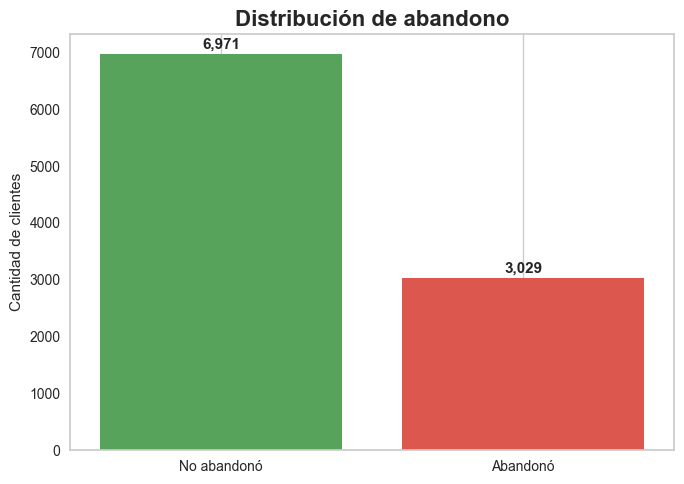

In [28]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=['No abandonó', 'Abandonó'],
    y=conteo.values,
    palette=['#4CAF50', '#F44336']
)

# Agregar cantidad y porcentaje
total = conteo.sum()

for i, valor in enumerate(conteo.values):
    porcentaje = valor / total * 100

    ax.text(
        i,
        valor + total * 0.01,
        f'{valor:,}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Distribución de abandono',
    fontsize=16,
    weight='bold'
)

plt.ylabel('Cantidad de clientes')
plt.xlabel('')
plt.grid()

plt.tight_layout()
plt.show()

In [11]:
df_riesgo_desafiliacion.columns

Index(['id_empresa', 'nit', 'sector', 'antiguedad', 'tiempo_afiliacion',
       'num_trabajadores', 'crecimiento_empleo', 'uso_servicios',
       'satisfaccion', 'rotacion', 'salario_promedio', 'digitalizacion',
       'formalizacion', 'distancia', 'abandono'],
      dtype='object')

In [12]:
df_riesgo_desafiliacion.groupby('uso_servicios').count()['abandono'].reset_index()

,uso_servicios,abandono
0,0,296
1,1,488
2,2,821
3,3,1190
4,4,1828
5,5,1974
6,6,1498
7,7,996
8,8,520
9,9,292


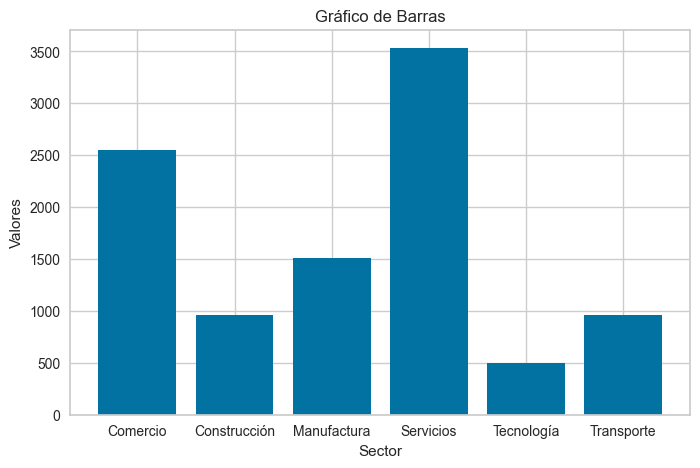

In [ ]:
# Datos
group = df_riesgo_desafiliacion['abandono'].value_counts()

# Gráfico
plt.figure(figsize=(8, 5))
plt.bar(group['sector'], group['abandono'])

# Títulos
plt.title('Gráfico de Barras')
plt.xlabel('Sector')
plt.ylabel('Valores')

plt.show()


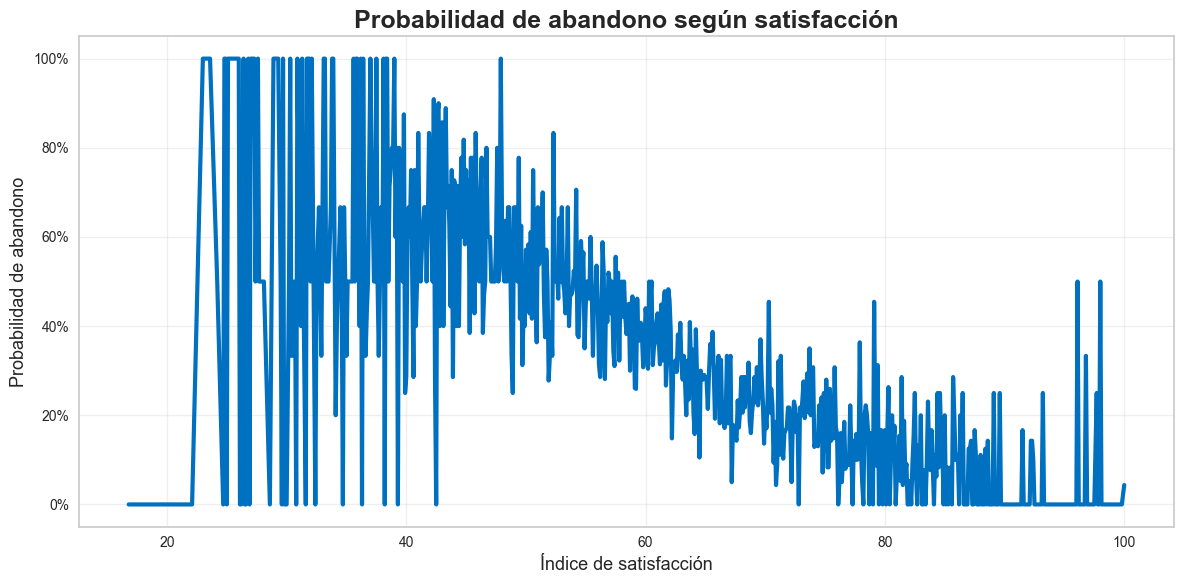

In [15]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_riesgo_desafiliacion,
    x='satisfaccion',
    y='abandono',
    estimator='mean',
    errorbar=None,
    color='#0070C0',
    linewidth=3
)

plt.title(
    'Probabilidad de abandono según satisfacción',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Índice de satisfacción', fontsize=13)
plt.ylabel('Probabilidad de abandono', fontsize=13)

plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

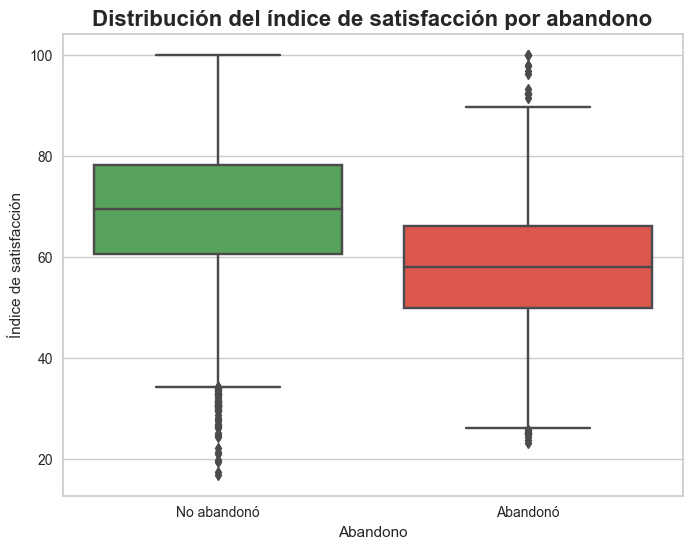

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_riesgo_desafiliacion,
    x='abandono',
    y='satisfaccion',
    palette=['#4CAF50', '#F44336']
)

plt.title('Distribución del índice de satisfacción por abandono',
          fontsize=16,
          weight='bold')

plt.xlabel('Abandono')
plt.ylabel('Índice de satisfacción')

plt.xticks([0,1],['No abandonó','Abandonó'])

plt.show()

In [48]:
tabla.sort_values(by='uso_servicios', ascending=False)

satisfaccion_bin,"(16.717, 25.12]","(25.12, 33.44]","(33.44, 41.76]","(41.76, 50.08]","(50.08, 58.4]","(58.4, 66.72]","(66.72, 75.04]","(75.04, 83.36]","(83.36, 91.68]","(91.68, 100.0]"
uso_servicios,,,,,,,,,,
10,NaN,NaN,NaN,NaN,NaN,0.500000,0.400000,0.176471,0.088235,0.051282
9,NaN,NaN,NaN,NaN,1.000000,0.083333,0.157895,0.082192,0.057471,0.024691
8,NaN,NaN,NaN,NaN,0.333333,0.100000,0.099174,0.098837,0.053097,0.045455
7,NaN,NaN,NaN,0.250000,0.480000,0.237705,0.144444,0.101911,0.050000,0.016393
6,NaN,NaN,0.000000,0.500000,0.405941,0.254072,0.165680,0.092437,0.073034,0.037037
5,NaN,0.000000,0.500000,0.608696,0.393836,0.260323,0.203526,0.133929,0.042254,0.000000
4,NaN,0.625000,0.535714,0.465116,0.389401,0.317324,0.232099,0.136646,0.258065,0.166667
3,NaN,0.857143,0.547619,0.580645,0.506775,0.385269,0.342246,0.410256,0.400000,0.000000
2,0.666667,0.833333,0.573171,0.546961,0.546429,0.458824,0.459459,0.294118,0.000000,NaN


In [60]:
pd.cut(df_riesgo_desafiliacion["satisfaccion"].round().astype(int), bins=10)

0       (50.2, 58.5]
1       (66.8, 75.1]
2       (50.2, 58.5]
3       (83.4, 91.7]
4       (66.8, 75.1]
            ...     
9995    (50.2, 58.5]
9996    (50.2, 58.5]
9997    (58.5, 66.8]
9998    (33.6, 41.9]
9999    (58.5, 66.8]
Name: satisfaccion, Length: 10000, dtype: category
Categories (10, interval[float64, right]): [(16.917, 25.3] < (25.3, 33.6] < (33.6, 41.9] < (41.9, 50.2] ... (66.8, 75.1] < (75.1, 83.4] < (83.4, 91.7] < (91.7, 100.0]]

In [58]:
df_riesgo_desafiliacion["satisfaccion"].round().astype(int)

0       58
1       71
2       58
3       85
4       72
        ..
9995    58
9996    57
9997    62
9998    38
9999    62
Name: satisfaccion, Length: 10000, dtype: int32

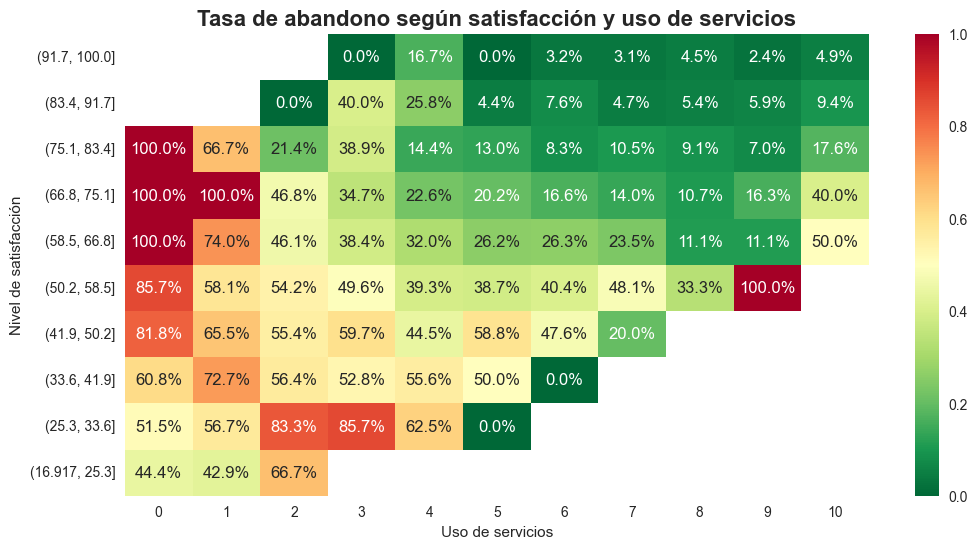

In [64]:

# Crear grupos
df_riesgo_desafiliacion["satisfaccion_bin"] = pd.cut(df_riesgo_desafiliacion["satisfaccion"].round().astype(int), bins=10)

tabla = (
    df_riesgo_desafiliacion.groupby(["satisfaccion_bin","uso_servicios"])["abandono"]
      .mean()
      .unstack()
)
tabla = tabla.sort_values(by='satisfaccion_bin', ascending=False)

plt.figure(figsize=(12,6))

sns.heatmap(
    tabla,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".1%"
)

plt.title(
    "Tasa de abandono según satisfacción y uso de servicios",
    fontsize=16,
    weight="bold"
)

plt.ylabel("Nivel de satisfacción")
plt.xlabel("Uso de servicios")
plt.grid()
plt.show()

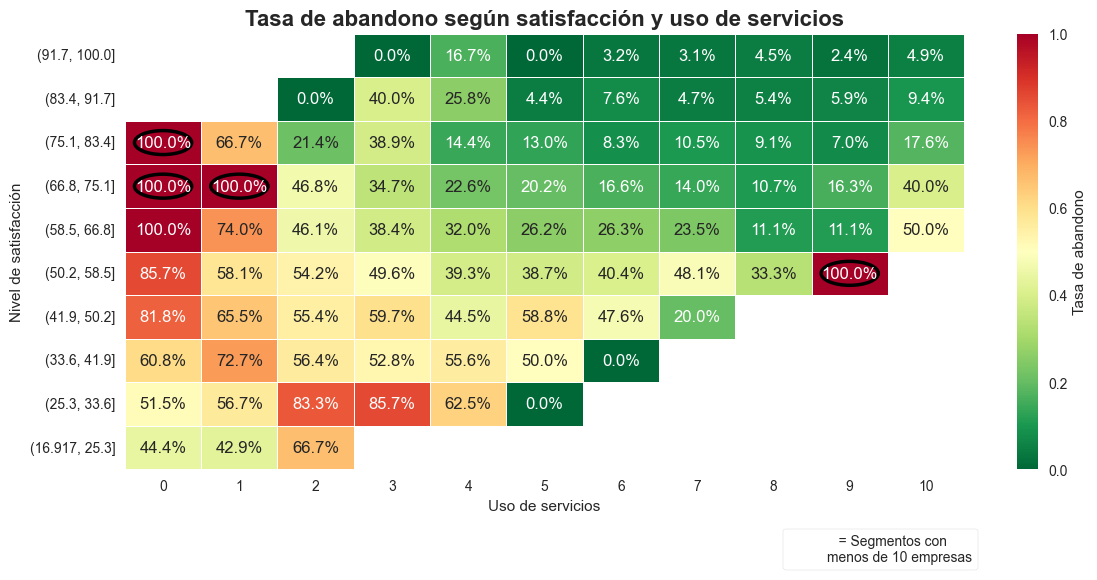

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Crear grupos
df_riesgo_desafiliacion["satisfaccion_bin"] = pd.cut(
    df_riesgo_desafiliacion["satisfaccion"].round().astype(int),
    bins=10,
)

# Tabla con tasa de abandono
tabla = (
    df_riesgo_desafiliacion
    .groupby(["satisfaccion_bin", "uso_servicios"])["abandono"]
    .mean()
    .unstack()
)

# Tabla con cantidad de registros
tabla_conteo = (
    df_riesgo_desafiliacion
    .groupby(["satisfaccion_bin", "uso_servicios"])["abandono"]
    .size()
    .unstack()
)

# Ordenar ambas tablas igual
tabla = tabla.sort_index(ascending=False)
tabla_conteo = tabla_conteo.reindex(tabla.index)

# Parámetro para definir pocos registros
min_registros = 10

plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    tabla,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".1%",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Tasa de abandono"}
)

from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

leyenda = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='black',
        markerfacecolor='none',
        markersize=10,
        linewidth=0,
        label='   = Segmentos con\nmenos de 10 empresas'
    )
]

ax.legend(
    handles=leyenda,
    loc='upper center',
    bbox_to_anchor=(0.9, -0.12),
    frameon=True
)

# Encerrar con círculo los valores 100% con pocos registros
for i, satisfaccion_bin in enumerate(tabla.index):
    for j, uso in enumerate(tabla.columns):

        tasa = tabla.loc[satisfaccion_bin, uso]
        cantidad = tabla_conteo.loc[satisfaccion_bin, uso]

        if pd.notna(tasa) and pd.notna(cantidad):
            if tasa == 1 and cantidad < min_registros:

                circulo = Ellipse(
                    xy=(j + 0.5, i + 0.5),   # centro de la celda
                    width=0.75,
                    height=0.55,
                    edgecolor="black",
                    facecolor="none",
                    linewidth=2.5
                )

                ax.add_patch(circulo)

plt.title(
    "Tasa de abandono según satisfacción y uso de servicios",
    fontsize=16,
    weight="bold"
)

plt.ylabel("Nivel de satisfacción")
plt.xlabel("Uso de servicios")
plt.grid()

plt.tight_layout()
plt.show()

### Correlacion de variables

In [36]:
df_riesgo_desafiliacion[['tiempo_afiliacion','antiguedad']]

,tiempo_afiliacion,antiguedad
0,1.5,2.8
1,8.1,13.3
2,44.4,50.0
3,4.4,7.0
4,8.0,9.5
...,...,...
9995,2.4,2.5
9996,4.3,5.9
9997,7.2,7.7
9998,7.2,7.8


                    id_empresa       nit  antiguedad  tiempo_afiliacion  \
id_empresa            1.000000 -0.007675   -0.003235           0.001200   
nit                  -0.007675  1.000000    0.004178           0.007552   
antiguedad           -0.003235  0.004178    1.000000           0.846235   
tiempo_afiliacion     0.001200  0.007552    0.846235           1.000000   
num_trabajadores      0.008041 -0.004197    0.012874           0.012267   
crecimiento_empleo   -0.009733  0.004165   -0.005798          -0.002936   
uso_servicios        -0.006689 -0.011301    0.001780           0.005151   
satisfaccion         -0.005262 -0.005031   -0.000035          -0.001038   
rotacion             -0.008244 -0.005934   -0.008494          -0.010445   
salario_promedio     -0.002242 -0.010441   -0.015577          -0.023695   
digitalizacion       -0.008300 -0.018899   -0.001621           0.000188   
formalizacion         0.000965 -0.005994   -0.006942          -0.006916   
distancia            -0.0

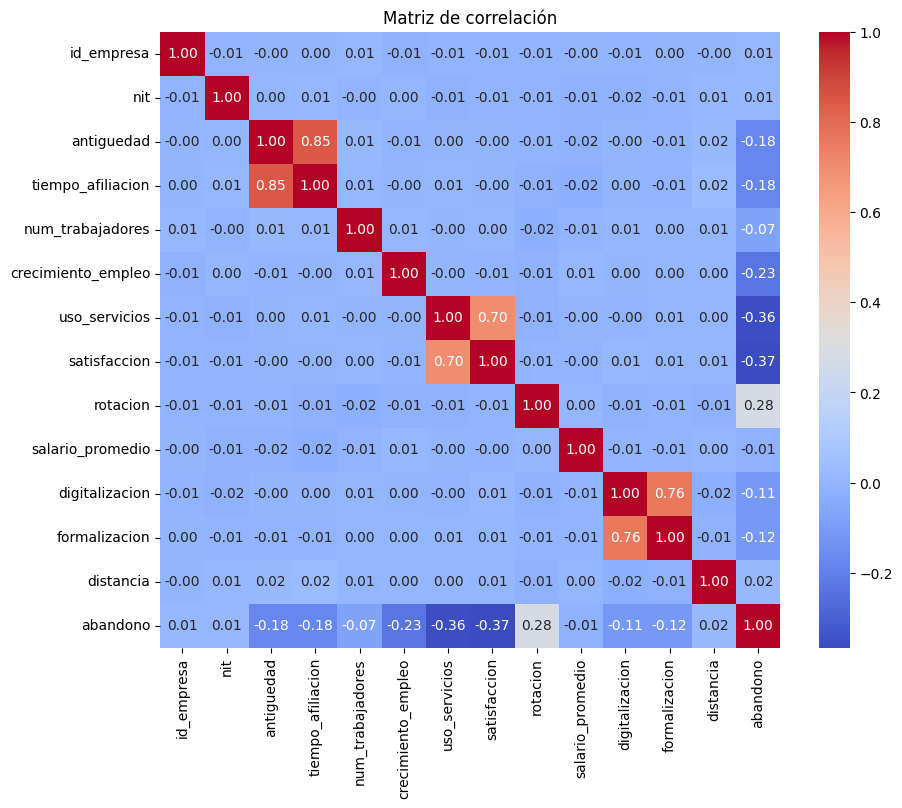

In [37]:
corr = df_riesgo_desafiliacion.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()


In [38]:
resultado_correlacion = correlacion_vs_target(df_riesgo_desafiliacion, target_col='abandono')
print(resultado_correlacion)


              variable  correlacion          metodo        p_value
0         satisfaccion     0.366165  Point-Biserial  6.278054e-315
1        uso_servicios     0.360179  Point-Biserial  4.776022e-304
2             rotacion     0.275466  Point-Biserial  1.359306e-173
3   crecimiento_empleo     0.234168  Point-Biserial  1.244089e-124
4    tiempo_afiliacion     0.179368  Point-Biserial   4.471173e-73
5           antiguedad     0.178109  Point-Biserial   4.598040e-72
6        formalizacion     0.115020  Point-Biserial   8.398388e-31
7       digitalizacion     0.110102  Point-Biserial   2.386413e-28
8     num_trabajadores     0.074967  Point-Biserial   6.082124e-14
9               sector     0.037674      Cramér's V   1.442742e-02
10           distancia     0.020760  Point-Biserial   3.789310e-02
11    salario_promedio     0.014468  Point-Biserial   1.479934e-01
12                 nit     0.012499  Point-Biserial   2.113789e-01
13          id_empresa     0.008090  Point-Biserial   4.185491

De acuerdo con los resultados obtenidos, se identifica que antigüedad y tiempo de afiliación son variables que estan altamente relacionadas y debido a su naturaleza contienen informacion redundande que indica cuanto tiempo lleva la empresa afiliada, por lo tanto se toma la decicion de dejar unicamente tiempo_afiliacion dado que es la más correlación tiene con el target, entre estas dos variables 